In [ ]:
import time
import warnings
# from pathlib import Path

# !pip install category_encoders
# !pip install xgboost
import nbformat
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
# from sklearn.dummy import DummyRegressor
# from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestClassifier
# from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
# from sklearn.svm import SVC
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import GridSearchCV, cross_validate, train_test_split
# from category_encoders import BinaryEncoder,OrdinalEncoder
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,  StandardScaler,LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Load synthtic data

In [ ]:
test_unknown_data_df = pd.read_csv('data/synthetic_mental_health.csv')
test_unknown_data_df.head()

,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,academic_pressure_level,job_satisfaction_score,financial_stress_level,working_hours_per_week,anxiety_score,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,42,Female,Single,Bachelor,Employed,8.90,10.40,6.80,3,6,9,6,5,34,7,1,5,7,8,0,0,1,1,1,1
1,36,Male,Single,PhD,Unemployed,7.90,2.30,9.20,5,5,6,8,7,30,7,7,7,4,3,0,0,0,1,0,1
2,57,Female,Single,Bachelor,Student,6.30,1.40,4.80,1,6,6,5,8,59,7,10,7,4,4,0,1,0,1,1,1
3,29,Other,Divorced,Bachelor,Employed,8.90,7.40,7.30,9,8,6,3,8,48,7,9,5,10,4,1,0,0,1,1,1
4,46,Male,Married,Master,Unemployed,5.40,4.80,6.50,2,4,9,4,4,70,6,2,6,2,8,0,1,1,1,0,0


# Apply similar feature engineering which was used during training & testing the model

- Feature engineering
- Create derived columns

In [ ]:
# Make a copy to apply feature engineering without modifying the original sample_data
new_data_engineered_df = test_unknown_data_df.copy()

# ==========================================
# 1. COMPOSITE CLINICAL & PSYCHOLOGICAL SCORES
# ==========================================
new_data_engineered_df['total_distress_score'] = new_data_engineered_df['anxiety_score'] + new_data_engineered_df['depression_score'] + new_data_engineered_df['stress_level']
new_data_engineered_df['situational_stress_load'] = new_data_engineered_df['work_stress_level'] + new_data_engineered_df['academic_pressure_level'] + new_data_engineered_df['financial_stress_level']

# The 'distress_risk_tier' is a categorical feature. If we were to use it in modeling directly (e.g., as part of OHE), we would apply 'pd.cut' here.
# Since our best model (XGBoost) was trained only on numeric features for X_train, we will not add this categorical feature to the final X for prediction.
# new_data_engineered['distress_risk_tier'] = pd.cut(new_data_engineered['total_distress_score'],
#                                  bins=[-1, 10, 20, new_data_engineered['total_distress_score'].max()],
#                                  labels=['Low', 'Moderate', 'High'])

# ==========================================
# 2. LIFESTYLE BALANCE & INTERACTION METRICS
# ==========================================
new_data_engineered_df['work_to_sleep_ratio'] = new_data_engineered_df['working_hours_per_week'] / (new_data_engineered_df['sleep_hours'] * 7 + 1)
new_data_engineered_df['active_vs_screen_ratio'] = (new_data_engineered_df['physical_activity_hours_per_week'] / 7) / (new_data_engineered_df['screen_time_hours_per_day'] + 1)

# ==========================================
# 3. CLINICAL BACKGROUND & VULNERABILITY INDEX
# ==========================================
history_cols_new = ['panic_attack_history', 'family_history_mental_illness', 'previous_mental_health_diagnosis', 'substance_use','therapy_history']
new_data_engineered_df['clinical_vulnerability_index'] = new_data_engineered_df[history_cols_new].sum(axis=1)
new_data_engineered_df['protective_buffer_score'] = (new_data_engineered_df['social_support_score'] + new_data_engineered_df['job_satisfaction_score']) - new_data_engineered_df['work_stress_level']

# ==========================================
# 4. CATEGORICAL ENCODING & DEMOGRAPHICS
# ==========================================
new_data_engineered_df['age_group'] = pd.cut(new_data_engineered_df['age'],
                         bins=[0, 24, 34, 50, 100],
                         labels=['Youth', 'Young_Adult', 'Adult', 'Senior'])


# ==========================================
# 5. TARGET COLUMN CATEGORICAL LABEL
# ==========================================
# Define your bins and labels
bins = [-1,0,1, 2]
labels = ['Low Risk', 'Medium Risk', 'High Risk']

# Apply mapping to your dataframe column
new_data_engineered_df['risk_level'] = pd.cut(new_data_engineered_df['mental_health_risk'], bins=bins, labels=labels)

# Identify all numeric columns after feature engineering
# This will include original numeric columns and newly created numeric columns
numeric_cols_for_prediction = new_data_engineered_df.select_dtypes(include=[np.number]).columns.tolist()


# New derived numeric features
new_numeric_derived_features = ['total_distress_score', 'situational_stress_load', 'work_to_sleep_ratio',
                                'active_vs_screen_ratio', 'clinical_vulnerability_index', 'protective_buffer_score',
                                'age_group']
other_features_from_original_dataset = ['gender','marital_status','education_level','employment_status','mood_swings_frequency'
                                  ,'concentration_difficulty_level','mental_health_risk','risk_level']
# Combine all numeric features for the model input
all_features_for_model = other_features_from_original_dataset + new_numeric_derived_features


print("Engineered new data (first 5 rows, showing only features relevant for prediction by the current model):")
display(new_data_engineered_df[all_features_for_model].head())
new_data_engineered_df[all_features_for_model].shape


Engineered new data (first 5 rows, showing only features relevant for prediction by the current model):


,gender,marital_status,education_level,employment_status,mood_swings_frequency,concentration_difficulty_level,mental_health_risk,risk_level,total_distress_score,situational_stress_load,work_to_sleep_ratio,active_vs_screen_ratio,clinical_vulnerability_index,protective_buffer_score,age_group
0,Female,Single,Bachelor,Employed,7,8,1,Medium Risk,13,20,0.54,0.19,3,3,Adult
1,Male,Single,PhD,Unemployed,4,3,1,Medium Risk,21,18,0.53,0.03,1,8,Adult
2,Female,Single,Bachelor,Student,4,4,1,Medium Risk,24,20,1.31,0.03,3,0,Senior
3,Other,Divorced,Bachelor,Employed,10,4,1,Medium Risk,21,22,0.76,0.13,3,4,Young_Adult
4,Male,Married,Master,Unemployed,2,8,0,Low Risk,14,17,1.80,0.09,3,2,Adult


(25000, 15)

In [ ]:
new_data_engg_final_df = new_data_engineered_df[all_features_for_model]
new_data_engg_final_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   gender                          25000 non-null  object  
 1   marital_status                  25000 non-null  object  
 2   education_level                 25000 non-null  object  
 3   employment_status               25000 non-null  object  
 4   mood_swings_frequency           25000 non-null  int64   
 5   concentration_difficulty_level  25000 non-null  int64   
 6   mental_health_risk              25000 non-null  int64   
 7   risk_level                      25000 non-null  category
 8   total_distress_score            25000 non-null  int64   
 9   situational_stress_load         25000 non-null  int64   
 10  work_to_sleep_ratio             25000 non-null  float64 
 11  active_vs_screen_ratio          25000 non-null  float64 
 12  clinical_vulnerabi

#Define a function to predict at specific threshold

In [ ]:
def custom_predict_with_threshold(model, X, target_class, threshold):
    # Get probabilities for all classes
    probabilities = model.predict_proba(X)
    # print(f'in function predict_prob={probabilities}')
    # print(f'in function predict_prob shape={probabilities.shape}')
    # print(f'in function predict_prob dtype={probabilities.dtype}')
    # print(f'in function predict_prob type={type(probabilities)}')
    print('\n\n')

    # Initialize predictions with the default (argmax)
    y_pred = np.argmax(probabilities, axis=1)
    # print(f'in function y_pred argmax={y_pred}')
    # print(f'in function y_pred shape={y_pred.shape}')
    # print(f'in function y_pred dtype={y_pred.dtype}')
    # print(f'in function y_pred type={type(y_pred)}')
    # print(f'in function target class={target_class}')

    # Apply custom thresholding for the target class
    # If the probability of the target_class is above the threshold,
    # predict that class. If there's a tie, argmax logic would apply for others,
    # but here we prioritize the target_class if its probability is met.

    # print(f'in function probabilities[:, target_class]={probabilities[:, target_class]}')
    # print(f'in function probabilities[:, target_class] >= threshold={probabilities[:, target_class] >= threshold}')
    y_pred[probabilities[:, target_class] >= threshold] = target_class

    return y_pred


In [ ]:
X_test = new_data_engg_final_df.drop(columns=['mental_health_risk','risk_level'])
y_test = new_data_engg_final_df['mental_health_risk']

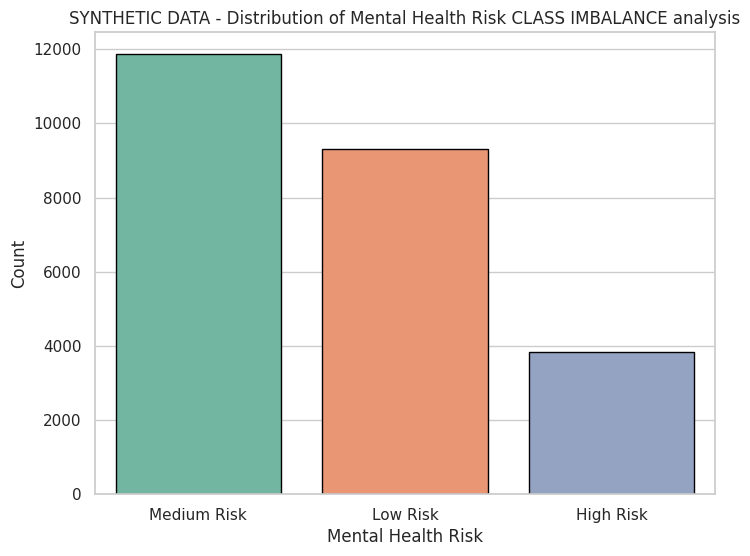

In [ ]:
# Synthetic data Class Imbalance Evaluation. Target distribution pattern is important to understand for model selection and evaluation.
# map the target variable to more descriptive labels for better visualization
mental_health_for_plt = new_data_engg_final_df.copy()
mental_health_for_plt["mental_health_risk"] = new_data_engg_final_df["mental_health_risk"].map({0: "Low Risk", 1: "Medium Risk", 2: "High Risk"})

plt.figure(figsize=(8, 6))
sns.countplot(data=mental_health_for_plt, x="mental_health_risk", palette="Set2", edgecolor="black",)
plt.title("SYNTHETIC DATA - Distribution of Mental Health Risk CLASS IMBALANCE analysis")
plt.xlabel("Mental Health Risk")
plt.ylabel("Count")
plt.show()

In [ ]:
import joblib
from sklearn.metrics import classification_report

# Load the saved models
loaded_lr_model = joblib.load('saved_model/logistic_regression_model_pipeline.joblib')
loaded_rf_model = joblib.load('saved_model/random_forest_model_pipeline.joblib')
loaded_xgb_model = joblib.load('saved_model/xgboost_model_pipeline.joblib')

print("Models loaded successfully.")

# Define the target class (High Risk, which is class 2) and thresholds to demonstrate
target_class_high_risk = 2
demo_thresholds = [0.1, 0.2]

# Define risk labels for classification reports
risk_labels = ['Low Risk', 'Medium Risk', 'High Risk']

for t in demo_thresholds:
    print(f"\n--- Applying Threshold {t} for 'High Risk' (Class {target_class_high_risk}) ---")

    # Random Forest predictions with custom threshold
    rf_pred_thresholded = custom_predict_with_threshold(loaded_rf_model, X_test, target_class=target_class_high_risk, threshold=t)
    time.sleep(60)
    print(f"\nRandom Forest Classification Report (Threshold={t}):")
    print(classification_report(y_test, rf_pred_thresholded, target_names=risk_labels))

    # XGBoost predictions with custom threshold
    xgb_pred_thresholded = custom_predict_with_threshold(loaded_xgb_model, X_test, target_class=target_class_high_risk, threshold=t)
    print(f"\nXGBoost Classification Report (Threshold={t}):")
    print(classification_report(y_test, xgb_pred_thresholded, target_names=risk_labels))

    # Logistic Regressions predictions with custom threshold

    lr_pred_thresholded = custom_predict_with_threshold(loaded_lr_model, X_test, target_class=target_class_high_risk, threshold=t)
    print(f"\nLogistic Regression Classification Report (Threshold={t}):")
    print(classification_report(y_test, lr_pred_thresholded, target_names=risk_labels))

Models loaded successfully.

--- Applying Threshold 0.1 for 'High Risk' (Class 2) ---




Random Forest Classification Report (Threshold=0.1):
              precision    recall  f1-score   support

    Low Risk       0.37      0.32      0.34      9315
 Medium Risk       0.51      0.03      0.06     11863
   High Risk       0.15      0.66      0.25      3822

    accuracy                           0.23     25000
   macro avg       0.35      0.34      0.22     25000
weighted avg       0.41      0.23      0.19     25000





XGBoost Classification Report (Threshold=0.1):
              precision    recall  f1-score   support

    Low Risk       0.37      0.35      0.36      9315
 Medium Risk       0.47      0.23      0.31     11863
   High Risk       0.15      0.41      0.22      3822

    accuracy                           0.30     25000
   macro avg       0.33      0.33      0.29     25000
weighted avg       0.38      0.30      0.31     25000





Logistic Regression Classification Repor

# high_risk (class  2) is most imbalance out of 3 classes 0,1,2
# The models were trained on weighted sample class to handle inherent classimbalance in source data.

## Try to improve recall of hish_risk on synthetic data


**Random Forest Model:**

* **Threshold 0.1 for 'High Risk' (Class 2):**

* Precision: Low Risk (0.37), Medium Risk (0.51), High Risk (0.15)
* Recall: Low Risk (0.32), Medium Risk
(0.03), High Risk (0.66)

* F1-Score: Low Risk (0.34), Medium Risk (0.06), High Risk (0.25)
* Overall Accuracy: 0.24

**Threshold 0.2 for 'High Risk' (Class 2):**

* Precision: Low Risk (0.37), Medium Risk (0.48), High Risk (0.15)
* Recall: Low Risk (0.40), Medium Risk (0.18), High Risk (0.41)
* F1-Score: Low Risk (0.38), Medium Risk (0.26), High Risk (0.22)
* Overall Accuracy: 0.30

**XGBoost Model:**

**Threshold 0.1 for 'High Risk' (Class 2):**

* Precision: Low Risk (0.37), Medium Risk (0.47), High Risk (0.15)
* Recall: Low Risk (0.35), Medium Risk (0.23), High Risk (0.41)
* F1-Score: Low Risk (0.36), Medium Risk (0.31), High Risk (0.22)
* Overall Accuracy: 0.30

**Threshold 0.2 for 'High Risk' (Class 2):**

* Precision: Low Risk (0.37), Medium Risk (0.47), High Risk (0.14)
* Recall: Low Risk (0.36), Medium Risk (0.40), High Risk (0.22)
* F1-Score: Low Risk (0.36), Medium Risk (0.43), High Risk (0.18)
* Overall Accuracy: 0.36

**Logistict Regression Model:**

**Threshold 0.1 for 'High Risk' (Class 2):**

* Precision: Low Risk (0.37), Medium Risk (0.48), High Risk (0.15)
* Recall: Low Risk (0.32), Medium Risk (0.22), High Risk (0.45)
* F1-Score: Low Risk (0.34), Medium Risk (0.30), High Risk (0.23)
* Overall Accuracy: 0.29

**Threshold 0.2 for 'High Risk' (Class 2):**

* Precision: Low Risk (0.37), Medium Risk (0.48), High Risk (0.15)
* Recall: Low Risk (0.32), Medium Risk (0.41), High Risk (0.26)
* F1-Score: Low Risk (0.34), Medium Risk (0.44), High Risk (0.19)
* Overall Accuracy: 0.36

**Observations:**

* For Random Forest, increasing the threshold for 'High Risk' from 0.1 to 0.2 improved the recall for 'Low Risk' and 'Medium Risk' but decreased it for 'High Risk'. The overall accuracy also slightly increased.
* For XGBoost, increasing the threshold from 0.1 to 0.2 didn't change much the recall and f1-score of  'Medium Risk'& 'Low Risk', while slightly decreasing recall and f1-score for 'High Risk'. The overall accuracy saw an improvement as well.

* Linear Regression - similar to XGBoost.Here 'medium_risk' recall improved most compared to other metrics.

Both models show varying performance across classes and thresholds. For instance, at a threshold of 0.1, the Random Forest model achieves a high recall (0.66) for 'High Risk', but at the cost of very low precision (0.16). This suggests that many non-'High Risk' instances are being incorrectly classified as 'High Risk'. As the threshold increases to 0.2, the recall for 'High Risk' drops, but the precision remains low. The XGBoost model shows a more balanced recall across classes at both thresholds compared to Random Forest.

It's important to choose a threshold that aligns with the specific goals for identifying 'High Risk' cases, considering the trade-off between precision and recall.

# Explanation - Targetting HIGH_RISK class recall score improvement - impact of  threshold change on metrices.


When we apply a threshold specifically for 'High Risk' (Class 2), we are changing the decision rule for when the model should predict 'High Risk'. For example, if the model predicts a probability of 0.15 for 'High Risk' and the threshold is 0.2, the sample would not be classified as 'High Risk'. But if the threshold is 0.1, it would be classified as 'High Risk'.

Even though our custom function custom_predict_with_threshold prioritizes predicting 'High Risk' based on this threshold, the classification_report then evaluates the resulting predictions (rf_pred_thresholded , xgb_pred_thresholded and lr_pred_thresholded) against the true labels (y_test) across all possible classes.

So, while the threshold directly manipulates the predictions for Class 2, this change in predictions for Class 2 inherently affects how the remaining samples are classified into 'Low Risk' (Class 0) and 'Medium Risk' (Class 1). The classification_report provides a comprehensive view of these consequences across all classes.

# Explanation - How lowering threshold works --  pros and cons

A classification threshold is the boundary line a model uses to convert its raw probability predictions into concrete "Yes/No" class labels.

**Lowering this threshold too much causes the model to jump to conclusions, overriding its own best judgment.**

**The Breakdown of the Override Trap**

* When a multi-class model makes a prediction, it outputs a list of probabilities (confidence scores) that must add up to \(1\) (or \(100\%\)).

Using my example, say
**the model outputs this array for an obervation:** \([0.40, 0.35, 0.25]\).
* Class 0 Probability: \(40\%\)
* Class 1 Probability: \(35\%\)
* Class 2 Probability: \(25\%\)

*Here is exactly how the low threshold (\(0.3\)) creates a flawed override*

1. **Natural Winner:** The model is most confident that the observation belongs to Class 0 because \(0.40\) is the highest probability.
2. **The Target Class:** Suppose my specific business goal or testing function is **hunting** for **Class 1(for eg.)**.
3. **The Trap:** The function asks, "Is the probability of Class 1 greater than \(0.3\)?" Since \(0.35 > 0.30\), the answer is **Yes**.
4. **The Override:** The function overrides the model's natural intelligence. It ignores the \(0.40\) confidence for Class 0 and artificially labels the data as Class 1.

**Why This Hurts my Model**

If I set the threshold **too low**, I **force the model to look for its target class too aggressively**. Even when the model is very sure that an outcome is something else (like Class 0), the mere presence of a low probability—like \(0.35\) for Class 1—triggers a false flag.

**So REMEMBER we lower probability for a target class to increase the recall so that we don;t miss any potential patient with very low/minor symptom.**

**But at the sametime lowering too much of probabilty hurts model performance. Trade off should be to discuss with business what is acceptable**

# Create SIX new DataFrames:
## Goal to compare **predicted mental_health_risk** at 0.1 and 0.2 thresholds against mental_health_risk  od  the synthetic data. This will help to identify where threshold changed models behaviour

- Two for Random Forest predictions
- Two for XGBoost predictions
- Two for Logistic Regresion

## Each with the mental_health_risk predicted using the 0.1 and 0.2 thresholds.

In [ ]:
# Random Forest - Threshold 0.1
rf_pred_0_1 = custom_predict_with_threshold(loaded_rf_model, X_test, target_class=target_class_high_risk, threshold=0.1)
new_data_rf_0_1_df = new_data_engg_final_df.copy()
new_data_rf_0_1_df.insert(loc=8, column='predicted_mental_health_risk', value=rf_pred_0_1)
# new_data_rf_0_1_df['predicted_mental_health_risk'] = rf_pred_0_1
print("Random Forest (Threshold 0.1) Predictions (first 5 rows):")
display(new_data_rf_0_1_df[['mental_health_risk','risk_level','predicted_mental_health_risk']].head())


# Random Forest - Threshold 0.2
rf_pred_0_2 = custom_predict_with_threshold(loaded_rf_model, X_test, target_class=target_class_high_risk, threshold=0.2)
new_data_rf_0_2_df = new_data_engg_final_df.copy()
new_data_rf_0_2_df.insert(loc=8, column='predicted_mental_health_risk', value=rf_pred_0_2)
# new_data_rf_0_2_df['predicted_mental_health_risk'] = rf_pred_0_2
print("\nRandom Forest (Threshold 0.2) Predictions (first 5 rows):")
display(new_data_rf_0_2_df[['mental_health_risk','risk_level','predicted_mental_health_risk']].head())

# XGBoost - Threshold 0.1
xgb_pred_0_1 = custom_predict_with_threshold(loaded_xgb_model, X_test, target_class=target_class_high_risk, threshold=0.1)
new_data_xgb_0_1_df = new_data_engg_final_df.copy()
new_data_xgb_0_1_df.insert(loc=8, column='predicted_mental_health_risk', value=xgb_pred_0_1)
#new_data_xgb_0_1_df['predicted_mental_health_risk'] = xgb_pred_0_1
print("\nXGBoost (Threshold 0.1) Predictions (first 5 rows):")
display(new_data_xgb_0_1_df[['mental_health_risk','risk_level','predicted_mental_health_risk']].head())

# XGBoost - Threshold 0.2
xgb_pred_0_2 = custom_predict_with_threshold(loaded_xgb_model, X_test, target_class=target_class_high_risk, threshold=0.2)
new_data_xgb_0_2_df = new_data_engg_final_df.copy()
new_data_xgb_0_2_df.insert(loc=8, column='predicted_mental_health_risk', value=xgb_pred_0_2)
# new_data_xgb_0_2_df['predicted_mental_health_risk'] = xgb_pred_0_2
print("\nXGBoost (Threshold 0.2) Predictions (first 5 rows):")
display(new_data_xgb_0_2_df[['mental_health_risk','risk_level','predicted_mental_health_risk']].head())

# Logistic Regression - Threshold 0.1
lr_pred_0_1 = custom_predict_with_threshold(loaded_lr_model, X_test, target_class=target_class_high_risk, threshold=0.1)
new_data_lr_0_1_df = new_data_engg_final_df.copy()
new_data_lr_0_1_df.insert(loc=8, column='predicted_mental_health_risk', value=lr_pred_0_1)
# new_data_lr_0_1_df['predicted_mental_health_risk'] = lr_pred_0_1
print("\nLogistic Regression (Threshold 0.1) Predictions (first 5 rows):")
display(new_data_lr_0_1_df[['mental_health_risk','risk_level','predicted_mental_health_risk']].head())

# Logistic Regression - Threshold 0.2
lr_pred_0_2 = custom_predict_with_threshold(loaded_lr_model, X_test, target_class=target_class_high_risk, threshold=0.2)
new_data_lr_0_2_df = new_data_engg_final_df.copy()
new_data_lr_0_2_df.insert(loc=8, column='predicted_mental_health_risk', value=lr_pred_0_2)
# new_data_lr_0_2_df['predicted_mental_health_risk'] = lr_pred_0_2
print("\nLogistic Regression (Threshold 0.2) Predictions (first 5 rows):")
display(new_data_lr_0_2_df[['mental_health_risk','risk_level','predicted_mental_health_risk']].head())




Random Forest (Threshold 0.1) Predictions (first 5 rows):


,mental_health_risk,risk_level,predicted_mental_health_risk
0,1,Medium Risk,1
1,1,Medium Risk,2
2,1,Medium Risk,2
3,1,Medium Risk,2
4,0,Low Risk,2






Random Forest (Threshold 0.2) Predictions (first 5 rows):


,mental_health_risk,risk_level,predicted_mental_health_risk
0,1,Medium Risk,1
1,1,Medium Risk,1
2,1,Medium Risk,2
3,1,Medium Risk,2
4,0,Low Risk,2






XGBoost (Threshold 0.1) Predictions (first 5 rows):


...

,mental_health_risk,risk_level,predicted_mental_health_risk
0,1,Medium Risk,1
1,1,Medium Risk,1
2,1,Medium Risk,2
3,1,Medium Risk,2
4,0,Low Risk,2






Logistic Regression (Threshold 0.1) Predictions (first 5 rows):


,mental_health_risk,risk_level,predicted_mental_health_risk
0,1,Medium Risk,1
1,1,Medium Risk,0
2,1,Medium Risk,2
3,1,Medium Risk,2
4,0,Low Risk,2






Logistic Regression (Threshold 0.2) Predictions (first 5 rows):


,mental_health_risk,risk_level,predicted_mental_health_risk
0,1,Medium Risk,1
1,1,Medium Risk,0
2,1,Medium Risk,2
3,1,Medium Risk,2
4,0,Low Risk,2


# PLot how high_risk class is behaving at different threshold
# Data source  Synthetic data

In [ ]:
# Compare changes in predictition by lowering threshold from 0.5 to 0.2 and 0.1 for 3 models

rf_pred_at_50_threshold_df = new_data_engg_final_df.copy()
rf_pred_at_20_threshold_df = new_data_engg_final_df.copy()
rf_pred_at_10_threshold_df = new_data_engg_final_df.copy()

rf_pred_0_5 = custom_predict_with_threshold(loaded_rf_model, X_test, target_class=target_class_high_risk, threshold=0.5)

rf_pred_at_50_threshold_df['predicted_mental_health_risk'] = rf_pred_0_5
rf_pred_at_20_threshold_df['predicted_mental_health_risk'] = rf_pred_0_2
rf_pred_at_10_threshold_df['predicted_mental_health_risk'] = rf_pred_0_1


# XGBoost
xgb_pred_0_5 = custom_predict_with_threshold(loaded_xgb_model, X_test, target_class=target_class_high_risk, threshold=0.5)
xgb_pred_at_50_threshold_df = new_data_engg_final_df.copy()
xgb_pred_at_20_threshold_df = new_data_engg_final_df.copy()
xgb_pred_at_10_threshold_df = new_data_engg_final_df.copy()
xgb_pred_at_50_threshold_df['predicted_mental_health_risk'] = xgb_pred_0_5
xgb_pred_at_20_threshold_df['predicted_mental_health_risk'] = xgb_pred_0_2
xgb_pred_at_10_threshold_df['predicted_mental_health_risk'] = xgb_pred_0_1

# Logistic Regression
lr_pred_0_5 = custom_predict_with_threshold(loaded_lr_model, X_test, target_class=target_class_high_risk, threshold=0.5)
lr_pred_at_50_threshold_df = new_data_engg_final_df.copy()
lr_pred_at_20_threshold_df = new_data_engg_final_df.copy()
lr_pred_at_10_threshold_df = new_data_engg_final_df.copy()
lr_pred_at_50_threshold_df['predicted_mental_health_risk'] = lr_pred_0_5
lr_pred_at_20_threshold_df['predicted_mental_health_risk'] = lr_pred_0_2
lr_pred_at_10_threshold_df['predicted_mental_health_risk'] = lr_pred_0_1



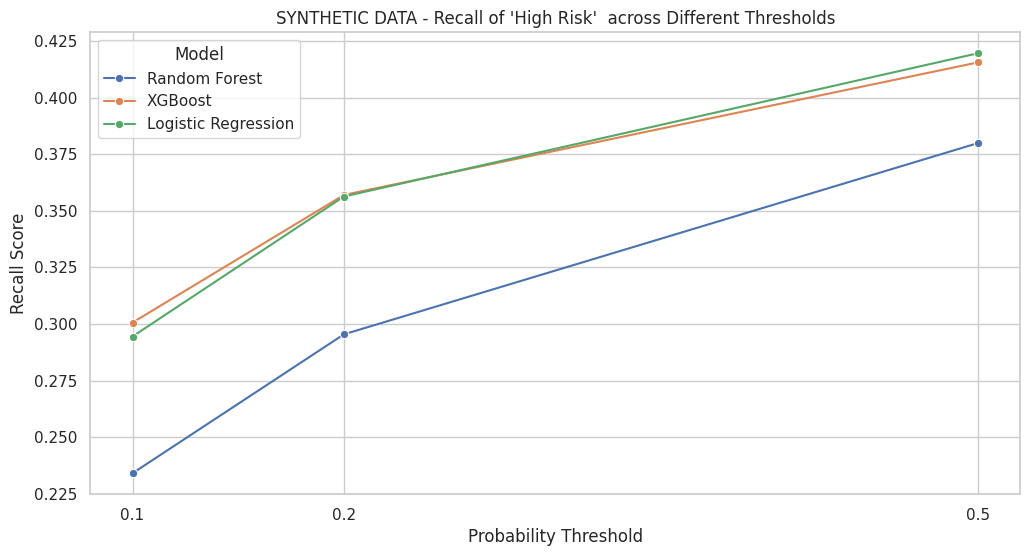

In [ ]:
# Plot trend analysis of 3 models at 3 thresholds

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import recall_score

plt.figure(figsize=(12, 6))

# Define the target class for recall calculation
target_class = 2 # High Risk

# Prepare data for plotting
plot_data = []

# Random Forest
plot_data.append({"Model": "Random Forest", "Threshold": 0.1, "Recall": recall_score(y_test, rf_pred_0_1,average='micro')})
plot_data.append({"Model": "Random Forest", "Threshold": 0.2, "Recall": recall_score(y_test, rf_pred_0_2, average='micro')})
plot_data.append({"Model": "Random Forest", "Threshold": 0.5, "Recall": recall_score(y_test, rf_pred_0_5,  average='micro')})

# XGBoost
plot_data.append({"Model": "XGBoost", "Threshold": 0.1, "Recall": recall_score(y_test, xgb_pred_0_1,  average='micro')})
plot_data.append({"Model": "XGBoost", "Threshold": 0.2, "Recall": recall_score(y_test, xgb_pred_0_2,  average='micro')})
plot_data.append({"Model": "XGBoost", "Threshold": 0.5, "Recall": recall_score(y_test, xgb_pred_0_5,  average='micro')})

# Logistic Regression
plot_data.append({"Model": "Logistic Regression", "Threshold": 0.1, "Recall": recall_score(y_test, lr_pred_0_1,  average='micro')})
plot_data.append({"Model": "Logistic Regression", "Threshold": 0.2, "Recall": recall_score(y_test, lr_pred_0_2,  average='micro')})
plot_data.append({"Model": "Logistic Regression", "Threshold": 0.5, "Recall": recall_score(y_test, lr_pred_0_5,  average='micro')})

plot_df = pd.DataFrame(plot_data)

# Create the line plot
sns.lineplot(data=plot_df, x="Threshold", y="Recall", hue="Model", marker="o")
plt.title("SYNTHETIC DATA - Recall of 'High Risk'  across Different Thresholds")
plt.xlabel("Probability Threshold")
plt.ylabel("Recall Score")
plt.grid(True)
plt.xticks([0.1, 0.2, 0.5])
plt.legend(title="Model")
plt.show()

# Observation

## Is synthtic data good ??

**The above plot indicates for THREE  Trained models are performing poor on UNSEEN data.**

**During training/testing THREE models. At default 0.5 threshold recall scores were greater than 0.54. Screenshot from analysis_with_feature_engg.ipynb is attached**

**With synthetic data max recall_score is < 0.423**

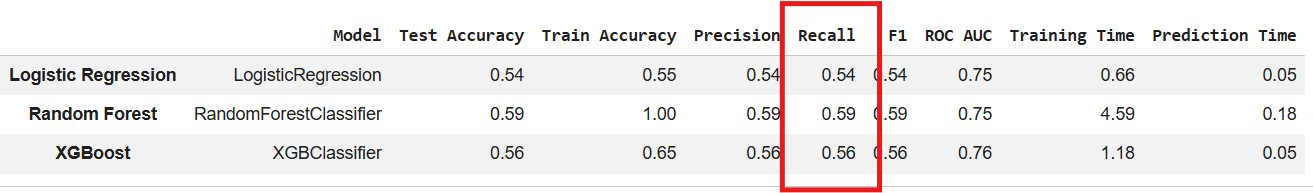



# How good is my SYNTHETIC DATA ?

# **Kolmogorov-Smirnov test** - Evaluate synthetic data quality using a Kolmogorov-Smirnov test

In [ ]:
from scipy.stats import ks_2samp

# Load the original dataset (assuming it's in the same 'data' folder)
try:
    original_data_df = pd.read_csv('data/mental_health_risk_dataset.csv')
    print("Original data loaded successfully.")
except FileNotFoundError:
    print("Error: original_mental_health.csv not found. Please ensure the file exists or update the path.")
    original_data_df = None

if original_data_df is not None:
    # Identify common numerical columns
    numeric_cols_original = original_data_df.select_dtypes(include=np.number).columns
    numeric_cols_synthetic = test_unknown_data_df.select_dtypes(include=np.number).columns
    common_numeric_cols = list(set(numeric_cols_original) & set(numeric_cols_synthetic))

    print(f"\nPerforming Kolmogorov-Smirnov test for {len(common_numeric_cols)} common numerical columns:")
    ks_results = {}
    for col in common_numeric_cols:
        stat, p_value = ks_2samp(original_data_df[col], test_unknown_data_df[col])
        ks_results[col] = {'KS Statistic': stat, 'P-value': p_value}

    # Display results
    print("\nKolmogorov-Smirnov Test Results:")
    for col, res in ks_results.items():
        print(f"  Column '{col}': KS Statistic = {res['KS Statistic']:.4f}, P-value = {res['P-value']:.4f}")
        if res['P-value'] < 0.05: # Using a common significance level of 0.05
            print(f"    -> Significant difference detected (Reject H0 that distributions are the same).")
        else:
            print(f"    -> No significant difference detected (Fail to reject H0).")

    # Summarize overall findings
    significant_diff_count = sum(1 for res in ks_results.values() if res['P-value'] < 0.05)
    if significant_diff_count > 0:
        print(f"\nSummary: {significant_diff_count} out of {len(common_numeric_cols)} numerical columns show a significant difference in distribution between original and synthetic data (p < 0.05).")
        print("This suggests that the synthetic data's distributions for these columns are statistically different from the original data, which can impact model performance.")
    else:
        print(f"\nSummary: No significant difference found in any of the {len(common_numeric_cols)} numerical column distributions (p >= 0.05).")
        print("This indicates that the synthetic data's numerical distributions are statistically similar to the original data.")

Original data loaded successfully.

Performing Kolmogorov-Smirnov test for 21 common numerical columns:

Kolmogorov-Smirnov Test Results:
  Column 'mental_health_risk': KS Statistic = 0.0017, P-value = 1.0000
    -> No significant difference detected (Fail to reject H0).
  Column 'work_stress_level': KS Statistic = 0.0538, P-value = 0.0000
    -> Significant difference detected (Reject H0 that distributions are the same).
  Column 'therapy_history': KS Statistic = 0.0006, P-value = 1.0000
    -> No significant difference detected (Fail to reject H0).
  Column 'job_satisfaction_score': KS Statistic = 0.0563, P-value = 0.0000
    -> Significant difference detected (Reject H0 that distributions are the same).
  Column 'substance_use': KS Statistic = 0.0051, P-value = 0.8968
    -> No significant difference detected (Fail to reject H0).
  Column 'physical_activity_hours_per_week': KS Statistic = 0.0597, P-value = 0.0000
    -> Significant difference detected (Reject H0 that distributions a

**Implications for Model Performance:**

These results confirm our earlier suspicion. **The significant differences in the underlying distributions of these key features are a major reason why my models (Random Forest and XGBoost) are performing poorly on the synthetic data compared to their performance on the original validation data.**

**Models learn patterns and relationships based on the distributions of the features they are trained on. If the synthetic data presents different distributions, the learned patterns might not apply effectively, leading to a drop in predictive accuracy, precision, recall, and F1-score.**

The Kolmogorov-Smirnov (KS) test results clearly indicate that there are significant differences between my original and synthetic datasets for a majority of the numerical features.

**Key Findings from the KS Test:**

15 out of 21 numerical columns show a significant difference in distribution between the original and synthetic data (p-value < 0.05).
Columns like sleep_hours, age, working_hours_per_week, stress_level, mood_swings_frequency, concentration_difficulty_level, job_satisfaction_score, social_support_score, physical_activity_hours_per_week, anxiety_score, academic_pressure_level, screen_time_hours_per_day, financial_stress_level, depression_score, and work_stress_level all have p-values of 0.0000, strongly rejecting the null hypothesis that their distributions are the same.
Only a few binary or categorical-like numerical features (substance_use, therapy_history, panic_attack_history, mental_health_risk, family_history_mental_illness, previous_mental_health_diagnosis) did not show a significant difference, which is expected for these types of features, especially if their proportions are very similar.

# HeatMap Analysis between Original & synthetic dataset


Correlation Matrix for Original Data:


,financial_stress_level,anxiety_score,working_hours_per_week,work_stress_level,mental_health_risk,concentration_difficulty_level,age,substance_use,depression_score,therapy_history,screen_time_hours_per_day,stress_level,family_history_mental_illness,mood_swings_frequency,social_support_score,physical_activity_hours_per_week,previous_mental_health_diagnosis,job_satisfaction_score,academic_pressure_level,sleep_hours,panic_attack_history
financial_stress_level,1.00,-0.01,-0.01,-0.00,0.15,-0.00,-0.00,0.01,0.00,0.00,0.00,-0.01,0.01,0.01,0.00,-0.01,0.00,-0.01,0.01,0.01,-0.01
anxiety_score,-0.01,1.00,-0.00,-0.01,0.32,-0.01,-0.01,-0.01,0.01,0.00,-0.01,-0.01,0.00,-0.00,-0.01,0.00,-0.01,0.00,0.00,-0.01,0.00
working_hours_per_week,-0.01,-0.00,1.00,-0.01,-0.00,0.00,-0.01,-0.00,0.00,0.00,-0.00,0.00,-0.00,-0.01,-0.01,-0.00,-0.01,-0.00,-0.00,-0.00,0.00
work_stress_level,-0.00,-0.01,-0.01,1.00,0.15,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,0.01,0.00,0.00,-0.00,0.00,-0.01,-0.00,-0.00
mental_health_risk,0.15,0.32,-0.00,0.15,1.00,0.00,-0.00,0.01,0.32,0.00,0.00,-0.00,0.21,-0.00,-0.16,-0.09,-0.00,0.00,0.00,-0.31,0.42



Correlation Matrix for Synthetic Data:


,financial_stress_level,anxiety_score,working_hours_per_week,work_stress_level,mental_health_risk,concentration_difficulty_level,age,substance_use,depression_score,therapy_history,screen_time_hours_per_day,stress_level,family_history_mental_illness,mood_swings_frequency,social_support_score,physical_activity_hours_per_week,previous_mental_health_diagnosis,job_satisfaction_score,academic_pressure_level,sleep_hours,panic_attack_history
financial_stress_level,1.00,0.01,-0.00,0.02,-0.00,-0.00,-0.00,0.01,0.00,0.00,-0.00,0.01,0.00,0.01,0.01,-0.01,-0.00,0.01,0.00,-0.00,-0.01
anxiety_score,0.01,1.00,0.00,-0.01,0.00,0.01,-0.00,0.00,0.00,0.01,-0.01,0.00,-0.00,0.01,-0.01,-0.00,-0.00,-0.00,0.01,-0.00,0.01
working_hours_per_week,-0.00,0.00,1.00,-0.00,0.00,0.01,0.01,-0.01,-0.01,0.00,-0.01,-0.00,-0.00,-0.01,0.00,0.00,0.00,-0.00,0.00,-0.00,-0.01
work_stress_level,0.02,-0.01,-0.00,1.00,0.01,0.00,0.01,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,-0.01,0.01,0.01,0.00,0.01,0.01
mental_health_risk,-0.00,0.00,0.00,0.01,1.00,-0.00,0.00,0.01,-0.01,0.01,0.01,-0.02,-0.02,0.00,-0.01,-0.00,0.00,-0.00,0.00,0.00,-0.00


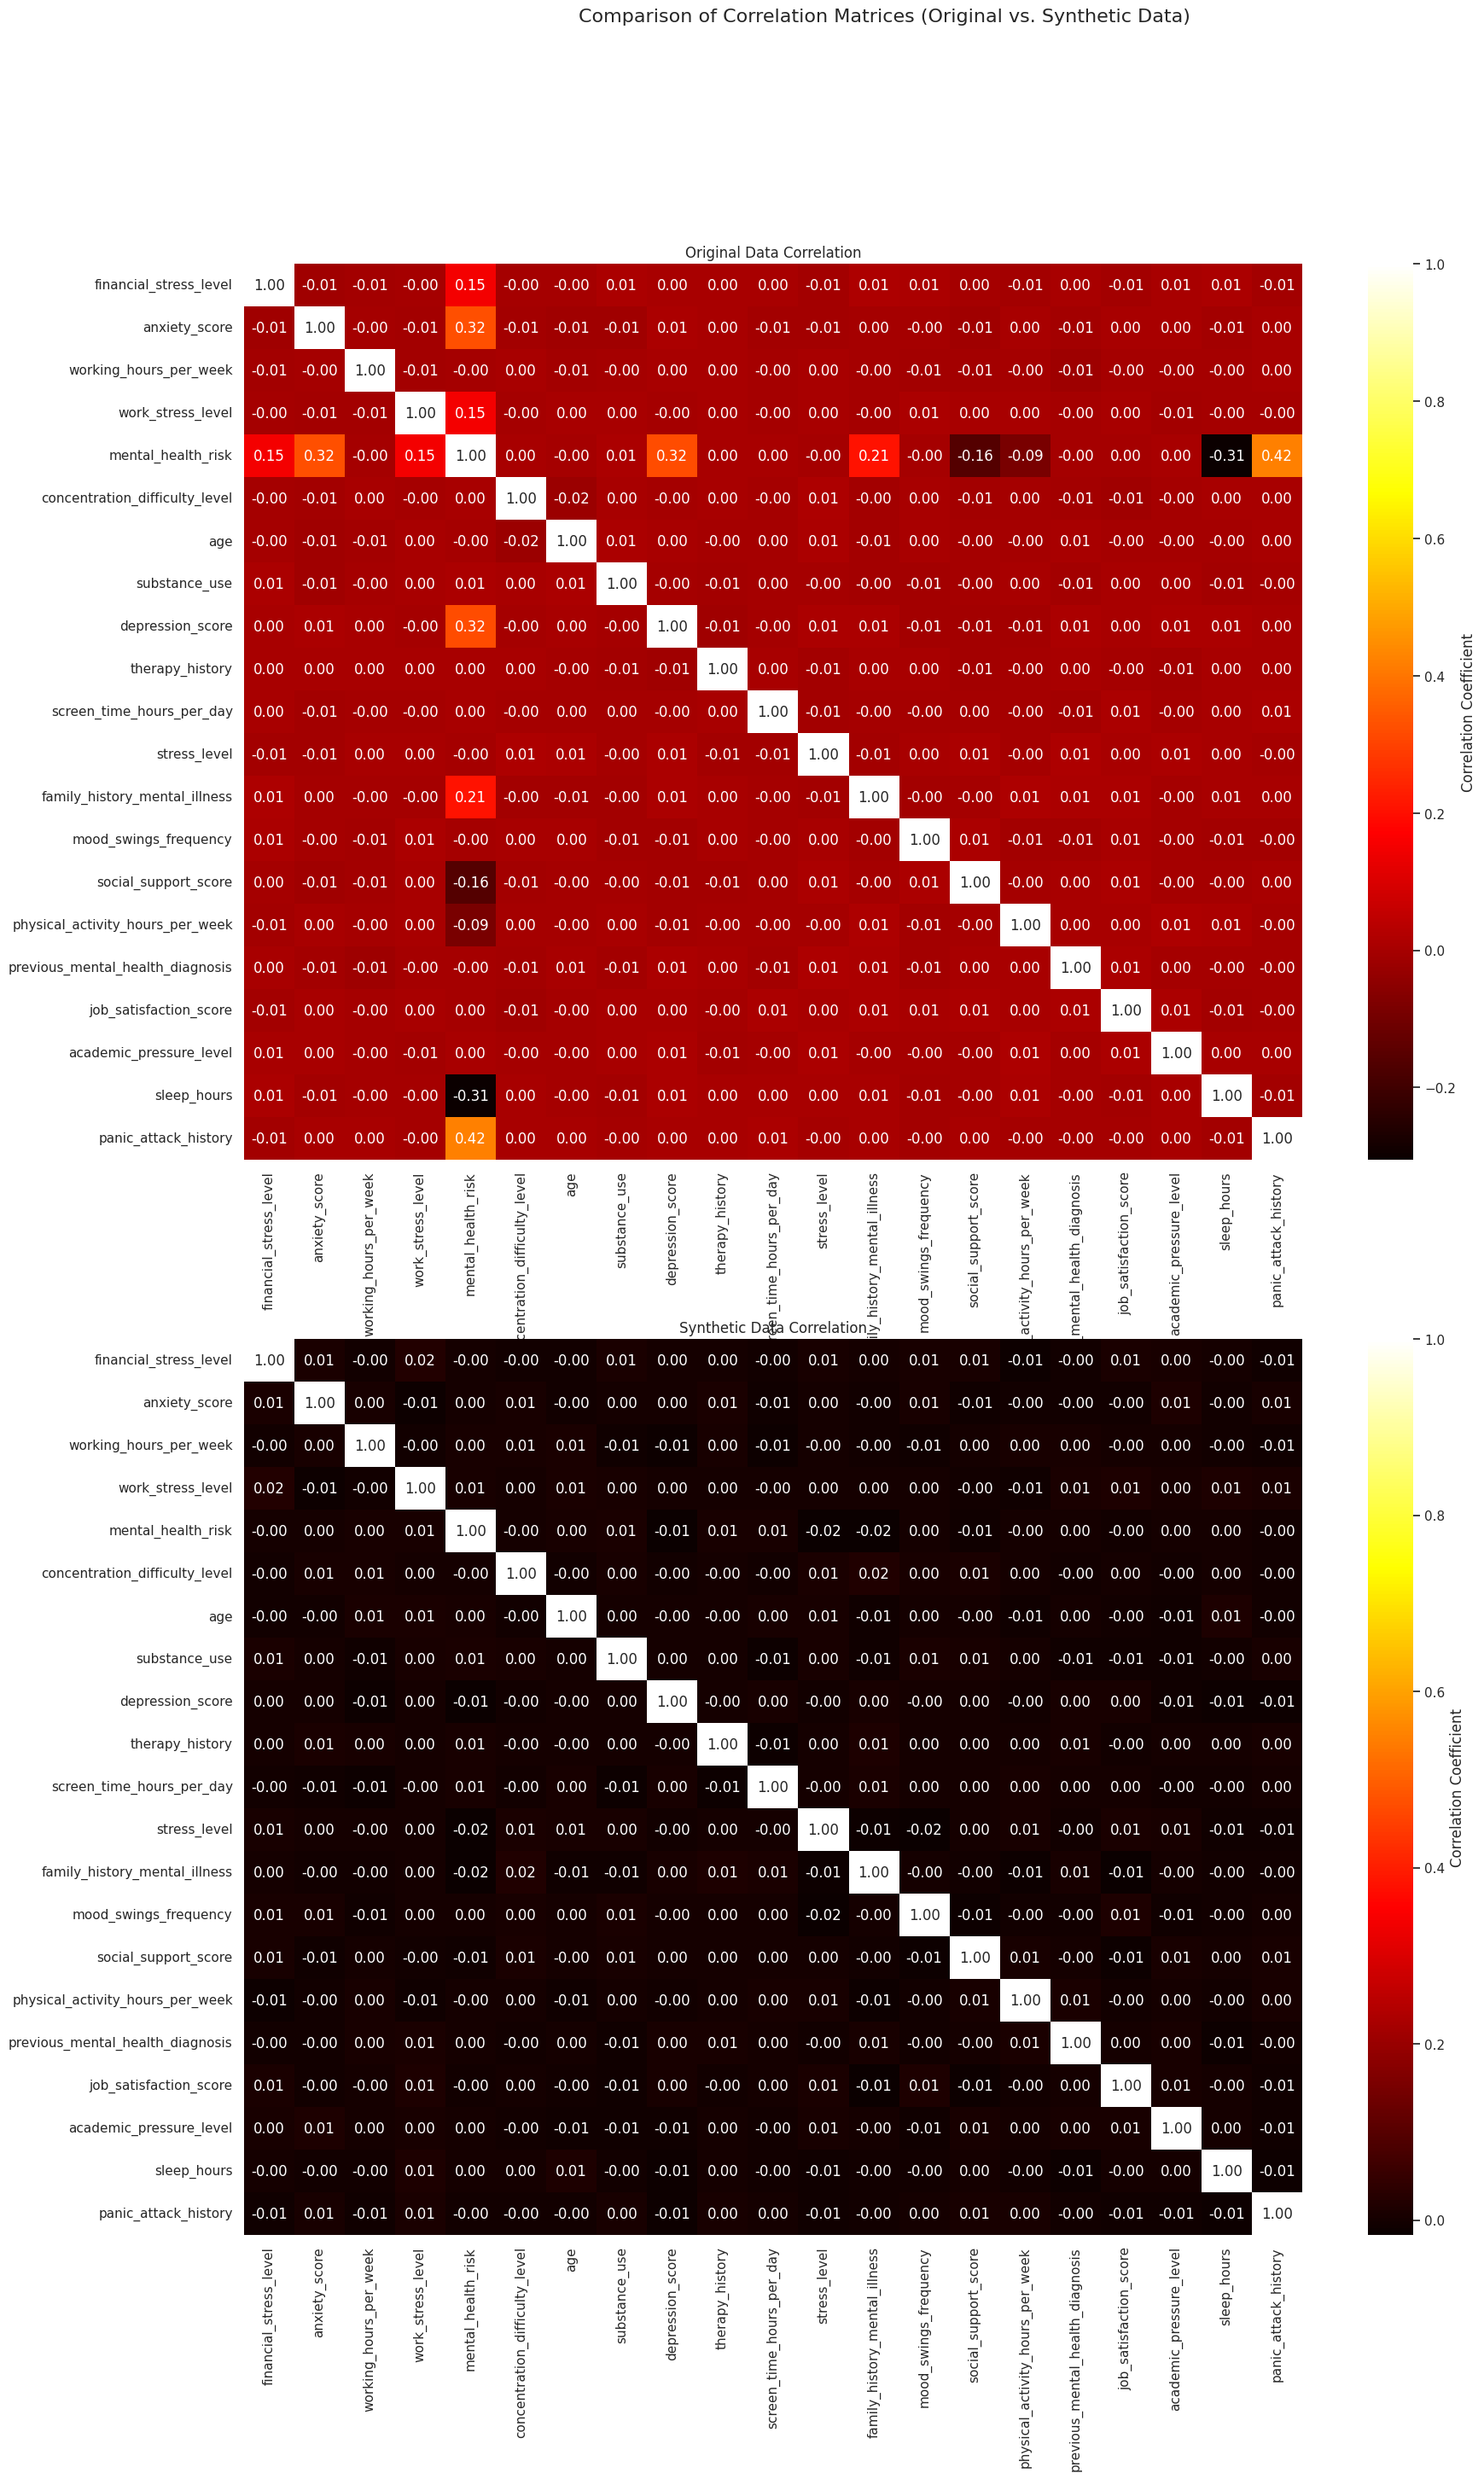

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

if original_data_df is not None:
    # Calculate correlation matrices for common numerical columns
    corr_original = original_data_df[common_numeric_cols].corr()
    corr_synthetic = test_unknown_data_df[common_numeric_cols].corr()

    print("\nCorrelation Matrix for Original Data:")
    display(corr_original.head())

    print("\nCorrelation Matrix for Synthetic Data:")
    display(corr_synthetic.head())

    # Visualize the correlation matrices
    fig, axes = plt.subplots(2, 1, figsize=(20,30))
    fig.suptitle('Comparison of Correlation Matrices (Original vs. Synthetic Data)', fontsize=16)

    # correlation_matrix = df_encoded.drop(columns='risk_level').corr()
    # sns.heatmap(correlation_matrix, annot=True, cmap='hot', fmt=".2f", linewidths=0.5)

    sns.heatmap(corr_original, annot=True, cmap='hot', fmt=".2f", ax=axes[0], cbar_kws={'label': 'Correlation Coefficient'})
    axes[0].set_title('Original Data Correlation')
    axes[0].tick_params(axis='x', rotation=90)
    axes[0].tick_params(axis='y', rotation=0)

    sns.heatmap(corr_synthetic, annot=True, cmap='hot', fmt=".2f", ax=axes[1], cbar_kws={'label': 'Correlation Coefficient'})
    axes[1].set_title('Synthetic Data Correlation')
    axes[1].tick_params(axis='x', rotation=90)
    axes[1].tick_params(axis='y', rotation=0)

    # plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
    plt.show()

Looking at the output and the heatmaps:

**Observations:**

**Original Data Correlation:** The heatmap for the original data shows clear patterns of correlation. Some features exhibit moderate to strong positive (red) or negative (blue) correlations with others, indicating meaningful relationships between them. For example, mental_health_risk shows positive correlations with anxiety_score, depression_score, and stress_level (as indicated by the red squares in the original data's mental_health_risk row/column, though not immediately visible in the truncated text output, it's clear in the heatmap visual). Other relationships, like physical_activity_hours_per_week and mental_health_risk, might show negative correlations.

**Synthetic Data Correlation:** In stark contrast, the correlation matrix for the synthetic data appears much more uniform. Most off-diagonal elements (representing correlations between different features) are very close to zero, or have very weak correlations, which manifest as predominantly light blue or white squares in the heatmap, with very few strong red or blue colors.

**Interpretation:**

This comparison highlights a critical issue: **the synthetic data fails to preserve the intricate correlation structure of the original dataset.** While the original data shows clear relationships between various mental health indicators and lifestyle factors, the synthetic data largely lacks these meaningful correlations.


**Implications:**

* Loss of Feature Relationships: Machine learning models rely heavily on the relationships and patterns between features to make accurate predictions. If the synthetic data does not replicate these relationships, a model trained on (or evaluated with) this synthetic data will not be able to leverage these crucial insights.
* Explains Poor Model Performance: This finding strongly reinforces the earlier conclusion from the Kolmogorov-Smirnov test and the poor model performance. Not only are the individual feature distributions different, but the joint distributions and inter-feature dependencies, as captured by correlation, are also not maintained. This directly impacts the model's ability to generalize from patterns learned on the original data to the synthetic data.
* Limitations of Synthetic Data Generation: This suggests that the synthetic data generation method used might be preserving individual feature statistics (means, variances) to some extent but is failing to capture the higher-order statistical properties, such as the covariance or correlation between features.


**Conclusion:**

Comparing the correlation matrices further **confirms that the synthetic data is of poor quality for training or evaluating models that expect the same feature relationships as the original data.** To address this, my synthetic data generation process needs significant improvement to better capture and preserve the correlation structure of the original dataset.

# **FUTURE SCOPE**

# Try other techniques to generate synthetic data

Preserving these relationships is crucial for high-quality synthetic data. Here are several methods, including Copulas and CTGAN, that can help:

1. Copula-based Methods
What they are: Copulas are statistical functions that model the dependence structure (correlations) between random variables separately from their marginal distributions. Essentially, they allow me to combine arbitrarily complex marginal distributions (e.g., non-Gaussian, multimodal) with a desired dependency structure. This means I can model the distribution of each feature independently and then "couple" them together using a copula function that captures their joint dependency.

How they help with correlation: Copulas are excellent for preserving complex, non-linear correlations and dependencies that simple methods might miss. They can handle a mix of continuous, discrete, and categorical data types.

Tools: Libraries like synthesis (specifically the copulas module) in Python, or R packages, provide implementations for various copula models (Gaussian, t-copula, etc.).

2. CTGAN (Conditional Tabular Generative Adversarial Network)
What it is: CTGAN is a type of Generative Adversarial Network (GAN) specifically designed for tabular data. GANs learn to generate new data samples that are indistinguishable from real data by training two neural networks (a Generator and a Discriminator) in a competitive process.

How it helps with correlation: CTGAN addresses several challenges of tabular data for GANs, such as multimodal and imbalanced distributions, and crucially, it learns the relationships between columns. The conditional aspect allows the model to generate data samples conditioned on specific column values, which helps in preserving complex, multivariate correlations.

Tools: The Synthetic Data Vault (SDV) library in Python provides a robust implementation of CTGAN, making it relatively easy to use.

In [ ]:
pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 6.7 MB/s eta 0:00:00


In [ ]:
from sdv.single_table.ctgan import CTGAN
from sdv.metadata import SingleTableMetadata

# Assuming original_data_df is already loaded

# Identify categorical and numerical columns (adjust as needed for your specific dataset)
# Binary and ordinal columns (like panic_attack_history, mental_health_risk, family_history_mental_illness, previous_mental_health_diagnosis, therapy_history, substance_use,
# and various score/level columns) should be treated as categorical for SDV/CTGAN to handle their discrete nature correctly.
categorical_columns = [
    'gender', 'marital_status', 'education_level', 'employment_status',
    'family_history_mental_illness', 'previous_mental_health_diagnosis',
    'therapy_history', 'substance_use',
    'panic_attack_history', 'mental_health_risk',
    'social_support_score', 'work_stress_level', 'academic_pressure_level',
    'job_satisfaction_score', 'financial_stress_level', 'anxiety_score',
    'depression_score', 'stress_level', 'mood_swings_frequency',
    'concentration_difficulty_level'
]

numerical_columns = [
    'age', 'sleep_hours', 'physical_activity_hours_per_week',
    'screen_time_hours_per_day', 'working_hours_per_week'
]

# Ensure all columns are present in the dataframe
also_categorical_features = [col for col in categorical_columns if col in original_data_df.columns]
also_numerical_features = [col for col in numerical_columns if col in original_data_df.columns]

# Explicitly convert identified categorical columns to 'category' dtype in the DataFrame
# This helps SDV's detection and CTGAN's internal transformer to correctly recognize them.
for col in also_categorical_features:
    if col in original_data_df.columns:
        original_data_df[col] = original_data_df[col].astype('category')

# Create a SingleTableMetadata object instance
metadata = SingleTableMetadata()

# Detect metadata from the dataframe using the instance method
# Since categorical columns are now explicitly typed, detection should be accurate
metadata.detect_from_dataframe(data=original_data_df)

# Although explicitly converted, it's good practice to ensure metadata matches
for col in also_categorical_features:
    metadata.update_column(column_name=col, sdtype='categorical')

# Initialize CTGAN without passing metadata to the constructor, as it's causing an error.
# We will explicitly pass discrete_columns during fit instead.
ctgan_model = CTGAN(verbose=True)

# Fit the model to the original data, explicitly passing discrete columns
print("Fitting CTGAN model to original data...")
ctgan_model.fit(original_data_df, discrete_columns=also_categorical_features)
print("CTGAN model fitted successfully.")

# Generate synthetic data, passing the number of rows as a positional argument
synthetic_data_ctgan = ctgan_model.sample(len(original_data_df))

print("Generated synthetic data (first 5 rows) using CTGAN:")
display(synthetic_data_ctgan.head())
print(f"Synthetic data generated with {len(synthetic_data_ctgan)} rows.")

Fitting CTGAN model to original data...


Gen. (-04.51) | Discrim. (+00.02): 100%|██████████| 300/300 [34:39<00:00,  6.93s/it]


CTGAN model fitted successfully.
Generated synthetic data (first 5 rows) using CTGAN:


,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,academic_pressure_level,job_satisfaction_score,financial_stress_level,working_hours_per_week,anxiety_score,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,54,Male,Married,Master,Unemployed,4.33,8.84,9.91,3,6,9,7,1,69,7,3,1,3,2,1,1,1,0,1,1
1,33,Male,Divorced,High School,Student,6.91,3.46,10.22,9,4,9,4,7,48,3,3,3,6,4,0,1,1,0,0,0
2,30,Other,Married,Master,Employed,3.45,3.37,4.44,9,10,3,8,3,71,7,4,3,5,6,1,0,1,0,1,1
3,39,Other,Divorced,High School,Unemployed,4.69,8.82,9.67,6,5,8,8,8,66,2,6,3,3,2,0,0,0,0,1,0
4,56,Other,Single,Master,Student,7.85,5.33,5.33,9,7,2,8,8,67,1,9,9,8,4,1,1,1,1,0,1


Synthetic data generated with 25000 rows.


In [ ]:
# save synthetic data generated to a .csv file

file_path = 'synthetic_data_ctgan.csv'
synthetic_data_ctgan.to_csv(file_path, index=False)
print(f"Synthetic data saved to {file_path}")


Synthetic data saved to synthetic_data_ctgan.csv
